# 01 - Data Types and Descriptive Statistics


## 1) Learning Objectives

- Identify qualitative and quantitative variables.
- Inspect a dataset correctly before analysis.
- Compute and interpret descriptive statistics.
- Compare groups with simple summaries.
- Connect summary tables to real analysis decisions.

## 2) Why This Topic Matters

Statistics starts with understanding your data. If we skip inspection or mix up variable types, later analysis can become misleading.

## 3) Short and Simple Theory Explanation

- **Qualitative (categorical) variable**: labels or categories (for example, city, gender).
- **Quantitative (numerical) variable**: numbers that measure something (for example, age, score).
- **Descriptive statistics** summarize data using center, spread, and counts.

## 4) Step-by-Step Code Examples

### Step 4.1 — Import libraries

- `import` loads Python packages we need.
- `numpy` (`np`) helps with numbers and random data.
- `pandas` (`pd`) helps with tables called **DataFrames**.
- `matplotlib.pyplot` (`plt`) creates plots.
- `np.random.seed(42)` makes random results repeatable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style='whitegrid')
print('Libraries loaded successfully.')

Libraries loaded successfully.


**Interpretation:** Setup is complete. Using the same seed each time helps classmates get the same synthetic dataset.

### Step 4.2 — Create a synthetic student dataset

We build a small table inside the notebook (no external file needed).
A **DataFrame** is like an Excel sheet in Python: rows are observations, columns are variables.

In [2]:
rng = np.random.default_rng(42)
number_of_students = 120

students = pd.DataFrame({
    'student_id': np.arange(1, number_of_students + 1),
    'age': rng.integers(18, 26, size=number_of_students),
    'exam_score': np.round(rng.normal(72, 10, number_of_students), 1),
    'study_hours': np.round(rng.normal(5, 2, number_of_students).clip(0.5, 14), 1),
    'part_time_income': np.round(rng.normal(450, 120, number_of_students).clip(0, None), 0),
    'gender': rng.choice(['Female', 'Male', 'Other'], size=number_of_students, p=[0.48, 0.48, 0.04]),
    'study_group': rng.choice(['Morning', 'Evening', 'Weekend'], size=number_of_students),
    'city': rng.choice(['Berlin', 'Munich', 'Hamburg'], size=number_of_students),
})

print('Dataset shape (rows, columns):', students.shape)
students.head()

Dataset shape (rows, columns): (120, 8)


,student_id,age,exam_score,study_hours,part_time_income,gender,study_group,city
0,1,18,63.3,4.8,239.0,Female,Weekend,Berlin
1,2,24,81.7,5.6,489.0,Female,Morning,Berlin
2,3,23,55.2,7.6,657.0,Female,Evening,Hamburg
3,4,21,68.7,5.4,266.0,Male,Morning,Hamburg
4,5,21,73.6,4.2,554.0,Male,Morning,Hamburg


**What is `head()`?** It shows the first 5 rows so we can quickly see column names and example values.

### Step 4.3 — Inspect structure with `info()` and `describe()`

- `info()` shows column names, data types, and missing values.
- `describe()` computes basic numerical summaries (mean, std, min, max, quartiles).

In [3]:
print('--- info() ---')
students.info()
print('\n--- describe() for numerical columns ---')
students.describe().round(2)

--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        120 non-null    int64  
 1   age               120 non-null    int64  
 2   exam_score        120 non-null    float64
 3   study_hours       120 non-null    float64
 4   part_time_income  120 non-null    float64
 5   gender            120 non-null    object 
 6   study_group       120 non-null    object 
 7   city              120 non-null    object 
dtypes: float64(3), int64(2), object(3)
memory usage: 7.6+ KB

--- describe() for numerical columns ---


,student_id,age,exam_score,study_hours,part_time_income
count,120.00,120.00,120.00,120.00,120.00
mean,60.50,21.68,70.82,5.00,455.52
std,34.79,2.23,9.10,2.00,122.95
min,1.00,18.00,50.70,0.50,170.00
25%,30.75,20.00,63.68,3.68,369.00
50%,60.50,22.00,70.25,4.80,474.00
75%,90.25,24.00,76.53,5.90,545.00
max,120.00,25.00,101.10,10.80,729.00


**Interpretation:** `describe()` gives a fast overview of numerical columns. For example, average exam score and how much scores vary (std).

### Step 4.4 — Identify variable types explicitly

We separate columns into **quantitative** (numbers) and **qualitative** (categories).

In [4]:
quantitative_columns = students.select_dtypes(include='number').columns.tolist()
qualitative_columns = students.select_dtypes(exclude='number').columns.tolist()

print('Quantitative columns:', quantitative_columns)
print('Qualitative columns:', qualitative_columns)

print('\nValue counts for study_group:')
print(students['study_group'].value_counts())

Quantitative columns: ['student_id', 'age', 'exam_score', 'study_hours', 'part_time_income']
Qualitative columns: ['gender', 'study_group', 'city']

Value counts for study_group:
study_group
Evening    49
Weekend    41
Morning    30
Name: count, dtype: int64


**What is `value_counts()`?** It counts how often each category appears. This is useful for qualitative variables.

### Step 4.5 — Grouped descriptive statistics

`groupby()` splits the table into groups, then we apply summary functions such as `mean()`.

In [5]:
grouped_means = students.groupby('study_group')[['exam_score', 'study_hours']].mean().round(2)
grouped_means

,exam_score,study_hours
study_group,,
Evening,70.53,4.69
Morning,70.96,5.44
Weekend,71.06,5.05


**Interpretation:** Morning, Evening, and Weekend groups can have different average scores. Grouped summaries reveal patterns that one overall mean may hide.

In [6]:
grouped_full = students.groupby('study_group').agg({
    'exam_score': ['mean', 'median', 'std'],
    'study_hours': ['mean', 'median'],
}).round(2)
grouped_full

exam_score               study_hours       
                  mean median    std        mean median
study_group                                            
Evening          70.53  71.50   8.84        4.69    4.7
Morning          70.96  67.85  11.38        5.44    5.3
Weekend          71.06  69.60   7.66        5.05    5.1

### Step 4.6 — Simple bar plot of group means

`plt.bar()` draws a bar chart. We plot average exam score by study group.

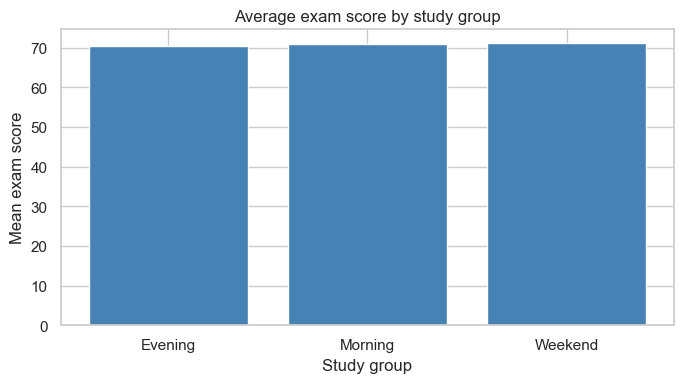

In [7]:
mean_scores = students.groupby('study_group')['exam_score'].mean()

plt.figure(figsize=(7, 4))
plt.bar(mean_scores.index, mean_scores.values, color='steelblue')
plt.title('Average exam score by study group')
plt.xlabel('Study group')
plt.ylabel('Mean exam score')
plt.tight_layout()
plt.show()

**Interpretation:** The plot makes group differences easier to see than numbers alone.

### Step 4.7 — Manual mean example (build intuition)

Packages compute quickly, but a manual example shows what `mean()` does.

In [8]:
small_scores = students['exam_score'].head(5)
print('First 5 exam scores:')
print(small_scores.values)

manual_mean = small_scores.sum() / len(small_scores)
pandas_mean = small_scores.mean()

print('Manual mean:', round(manual_mean, 2))
print('pandas mean():', round(pandas_mean, 2))

First 5 exam scores:
[63.3 81.7 55.2 68.7 73.6]
Manual mean: 68.5
pandas mean(): 68.5


**Interpretation:** Both methods match. Mean = sum of values divided by count.

## 7) Summary Interpretation

We created and inspected a student table, separated variable types, and compared groups with tables and a bar chart.

## 8) Student Check Questions

### Question 1 (Conceptual)
Why do we separate qualitative and quantitative variables before analysis?

**Suggested answer:**
They need different summaries and plots. Means are meaningful for numbers, while counts or bar charts are better for categories.

### Question 2 (Small code change)
Change the grouping column from `study_group` to `city` and compare the mean `exam_score` for each city.

Try the change in a new code cell below and write one sentence about what you observed.

In [9]:
# Your code change for Question 2 goes here.


## 9) Key Takeaways

- Inspect before interpreting.
- Variable types are foundational.
- Grouped descriptive statistics are more informative than one global number.
- Manual checks improve statistical intuition.

## 10) Optional Short Practice / Challenge

Convert `gender` and `city` to pandas `category` dtype using `.astype('category')`, then run `info()` again.

## 11) Code Refinement Tasks — Check Your Understanding

Complete **both** refinements below. This checks whether you understood the notebook, not only whether you can run it.

**Instructions:**
1. Read each task carefully.
2. Write or change Python code in the cells below.
3. **Run each cell** (and rerun earlier cells if needed).
4. Compare the new output with the original notebook results.
5. Write a short note: *What changed? Did it match your expectation?*

### Refinement 1
In **Step 4.5**, change the grouping column from `'study_group'` to `'city'`. Recompute the mean `exam_score` for each city and display the table. Which city has the highest average score in your synthetic data?

### Refinement 2
Create a filtered table with only students where `age >= 20`, then run `.describe()` on `exam_score`. Compare the mean with the mean from the full dataset. Did filtering change the average much?

In [10]:
# Refinement 1 — your code here
# After editing, run this cell and describe the result in one sentence.


In [11]:
# Refinement 2 — your code here
# After editing, run this cell and describe the result in one sentence.


**Reflection (write in your own words):**
- Refinement 1: What did you change, and what happened after rerun?
- Refinement 2: What did you change, and what happened after rerun?
- Do you understand *why* the output changed?

In [12]:
print('Notebook 01 completed successfully.')

Notebook 01 completed successfully.
